# Task-3 Linear Regression


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df=pd.read_csv("Housing.csv")
df.shape

(545, 13)

In [3]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [5]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [7]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [8]:
df = df.drop_duplicates()

In [9]:
# 1a. Encode binary yes/no categorical columns as 1/0
binary_cols = ["mainroad", "guestroom", "basement", "hotwaterheating",
               "airconditioning", "prefarea"]
for col in binary_cols:
    df[col] = df[col].map({"yes": 1, "no": 0})

In [10]:
# 1b. One-hot encode the 3-level 'furnishingstatus' column (drop_first avoids
#     the dummy-variable trap / multicollinearity)
df = pd.get_dummies(df, columns=["furnishingstatus"], drop_first=True)
# resulting new columns: furnishingstatus_semi-furnished, furnishingstatus_unfurnished
df = df.rename(columns={
    "furnishingstatus_semi-furnished": "furnishing_semi",
    "furnishingstatus_unfurnished": "furnishing_unfurnished",
})

In [11]:
# ensure these are proper 0/1 ints (get_dummies can return bool dtype)
for c in ["furnishing_semi", "furnishing_unfurnished"]:
    df[c] = df[c].astype(int)


In [12]:
print("\nColumns after encoding:\n", df.columns.tolist())
print("\nCleaned data sample:\n", df.head())
print(f"\nShape after cleaning: {df.shape}")


Columns after encoding:
 ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishing_semi', 'furnishing_unfurnished']

Cleaned data sample:
       price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1    

In [13]:
# 2. TRAIN-TEST SPLIT
# -----------------------------------------------------------------
print("\n" + "=" * 60)
print("STEP 2: Train-test split")
print("=" * 60)


STEP 2: Train-test split


In [14]:
# ---- Part A: SIMPLE Linear Regression (1 feature: area -> price) ----
X_simple = df[["area"]]
y = df["price"]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)
print(f"Simple regression   -> train: {X_train_s.shape[0]}, test: {X_test_s.shape[0]}")

Simple regression   -> train: 436, test: 109


In [15]:
# ---- Part B: MULTIPLE Linear Regression (all features -> price) ----
FEATURES = [
    "area", "bedrooms", "bathrooms", "stories", "mainroad", "guestroom",
    "basement", "hotwaterheating", "airconditioning", "parking", "prefarea",
    "furnishing_semi", "furnishing_unfurnished",
]
X_multi = df[FEATURES]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)
print(f"Multiple regression -> train: {X_train_m.shape[0]}, test: {X_test_m.shape[0]}")

Multiple regression -> train: 436, test: 109


In [16]:
# 3. FIT LINEAR REGRESSION MODELS
# -----------------------------------------------------------------
print("\n" + "=" * 60)
print("STEP 3: Fitting Linear Regression models")
print("=" * 60)

simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train_s)

multi_model = LinearRegression()
multi_model.fit(X_train_m, y_train_m)

print("Simple model fit complete.")
print("Multiple model fit complete.")


STEP 3: Fitting Linear Regression models
Simple model fit complete.
Multiple model fit complete.


In [17]:
def evaluate(model, X_test, y_test, name):
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)
    print(f"\n--- {name} ---")
    print(f"MAE  : {mae:,.2f}")
    print(f"MSE  : {mse:,.2f}")
    print(f"RMSE : {rmse:,.2f}")
    print(f"R²   : {r2:.4f}")
    return preds, mae, mse, rmse, r2

In [18]:
preds_s, mae_s, mse_s, rmse_s, r2_s = evaluate(
    simple_model, X_test_s, y_test_s, "Simple Linear Regression (area -> price)"
)
preds_m, mae_m, mse_m, rmse_m, r2_m = evaluate(
    multi_model, X_test_m, y_test_m, "Multiple Linear Regression (all features -> price)"
)


--- Simple Linear Regression (area -> price) ---
MAE  : 1,474,748.13
MSE  : 3,675,286,604,768.19
RMSE : 1,917,103.70
R²   : 0.2729

--- Multiple Linear Regression (all features -> price) ---
MAE  : 970,043.40
MSE  : 1,754,318,687,330.66
RMSE : 1,324,506.96
R²   : 0.6529


In [19]:

# -----------------------------------------------------------------
# 5. PLOT REGRESSION LINE & INTERPRET COEFFICIENTS
# -----------------------------------------------------------------
print("\n" + "=" * 60)
print("STEP 5: Coefficient interpretation")
print("=" * 60)

print(f"\nSimple model: price = {simple_model.intercept_:,.2f} + {simple_model.coef_[0]:,.2f} * area")
print(f"Interpretation: each extra 1 sq.ft of area is associated with a change")
print(f"of {simple_model.coef_[0]:,.2f} in price, holding nothing else constant.")

print("\nMultiple model coefficients:")
print(f"Intercept: {multi_model.intercept_:,.2f}")
coef_table = pd.DataFrame({"feature": FEATURES, "coefficient": multi_model.coef_})
coef_table = coef_table.sort_values("coefficient", key=abs, ascending=False)
print(coef_table.to_string(index=False))

print("\nPlain-language interpretation (holding other features constant):")
for feat, coef in zip(FEATURES, multi_model.coef_):
    if feat in binary_cols or feat in ["furnishing_semi", "furnishing_unfurnished"]:
        print(f"  {feat:24s}: having this feature changes price by {coef:,.2f}")
    else:
        print(f"  {feat:24s}: +1 unit changes price by {coef:,.2f}")


STEP 5: Coefficient interpretation

Simple model: price = 2,512,254.26 + 425.73 * area
Interpretation: each extra 1 sq.ft of area is associated with a change
of 425.73 in price, holding nothing else constant.

Multiple model coefficients:
Intercept: 260,032.36
               feature   coefficient
             bathrooms  1.094445e+06
       airconditioning  7.914267e+05
       hotwaterheating  6.846499e+05
              prefarea  6.298906e+05
furnishing_unfurnished -4.136451e+05
               stories  4.074766e+05
              basement  3.902512e+05
              mainroad  3.679199e+05
             guestroom  2.316100e+05
               parking  2.248419e+05
       furnishing_semi -1.268818e+05
              bedrooms  7.677870e+04
                  area  2.359688e+02

Plain-language interpretation (holding other features constant):
  area                    : +1 unit changes price by 235.97
  bedrooms                : +1 unit changes price by 76,778.70
  bathrooms               : +1 

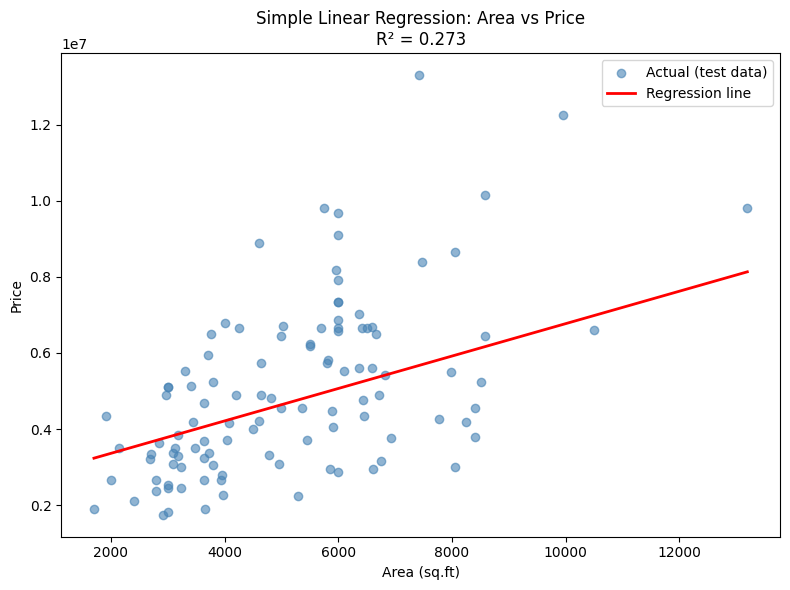

In [22]:
# --- Plot 1: Simple regression line over scatter of test data ---
plt.figure(figsize=(8, 6))
plt.scatter(X_test_s, y_test_s, color="steelblue", alpha=0.6, label="Actual (test data)")
order = np.argsort(X_test_s["area"].values)
plt.plot(X_test_s["area"].values[order], preds_s[order], color="red", linewidth=2, label="Regression line")
plt.xlabel("Area (sq.ft)")
plt.ylabel("Price")
plt.title(f"Simple Linear Regression: Area vs Price\nR² = {r2_s:.3f}")
plt.legend()
plt.tight_layout()
plt.show()
plt.close()

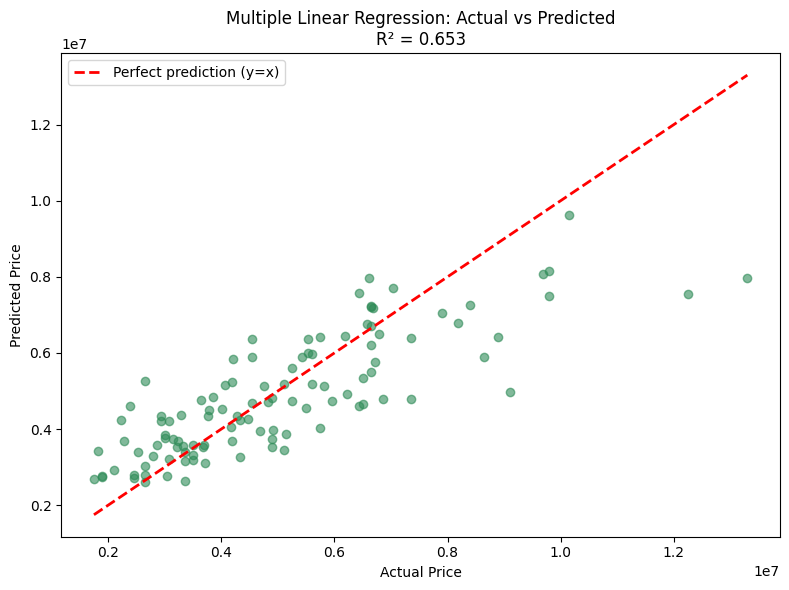

In [24]:
# --- Plot 2: Actual vs Predicted for multiple regression ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test_m, preds_m, color="seagreen", alpha=0.6)
lims = [min(y_test_m.min(), preds_m.min()), max(y_test_m.max(), preds_m.max())]
plt.plot(lims, lims, color="red", linewidth=2, linestyle="--", label="Perfect prediction (y=x)")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Multiple Linear Regression: Actual vs Predicted\nR² = {r2_m:.3f}")
plt.legend()
plt.tight_layout()
plt.show()
plt.close()

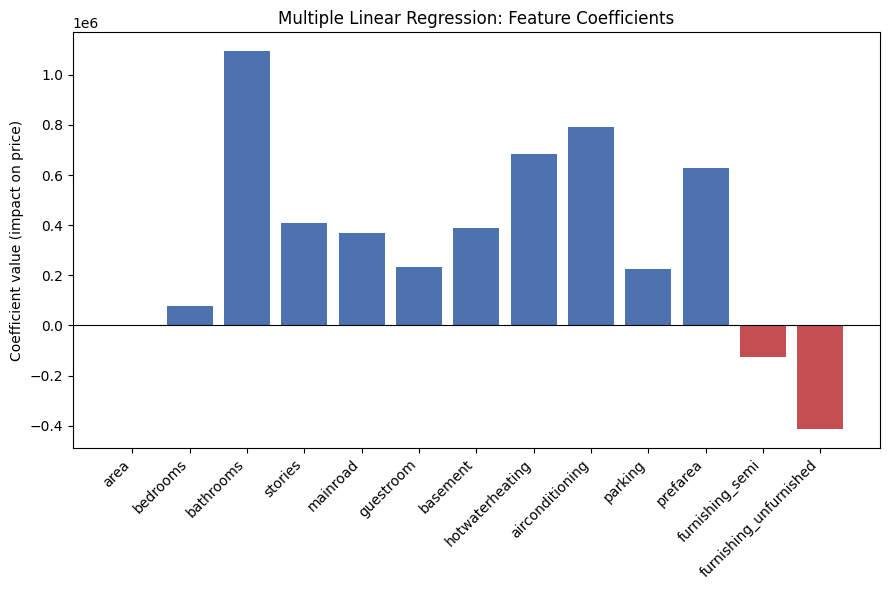

In [25]:
# --- Plot 3: Coefficient bar chart for multiple regression ---
plt.figure(figsize=(9, 6))
colors = ["#4C72B0" if c >= 0 else "#C44E52" for c in multi_model.coef_]
plt.bar(FEATURES, multi_model.coef_, color=colors)
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Coefficient value (impact on price)")
plt.title("Multiple Linear Regression: Feature Coefficients")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
plt.close()

In [26]:
# Save metrics summary + coefficient table
summary = pd.DataFrame({
    "Model": ["Simple (area only)", "Multiple (all features)"],
    "MAE": [mae_s, mae_m],
    "MSE": [mse_s, mse_m],
    "RMSE": [rmse_s, rmse_m],
    "R2": [r2_s, r2_m],
})
summary.to_csv("metrics_summary.csv", index=False)
coef_table.to_csv("multiple_regression_coefficients.csv", index=False)

print("\nSaved metrics_summary.csv:")
print(summary)
print("\nSaved multiple_regression_coefficients.csv")


Saved metrics_summary.csv:
                     Model           MAE           MSE          RMSE        R2
0       Simple (area only)  1.474748e+06  3.675287e+12  1.917104e+06  0.272879
1  Multiple (all features)  9.700434e+05  1.754319e+12  1.324507e+06  0.652924

Saved multiple_regression_coefficients.csv
